<a href="https://colab.research.google.com/github/mailan48692004-web/Used-Car-Pricing-Analytics/blob/main/notebook/used_car_pricing_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 1. BUSINESS UNDERSTANDING
This notebook analyses the U.S. used car market using Craigslist listing data to support Apex Autos' market expansion decision into the United States.

# Main objectives:
1. Assess data quality
2. Understand the distribution of listing_price
3. Explore how vehicle attributes and regional factors relate to price
4. Analyse the availability of vehicle types across regions
5. Generate actionable business recommendations


Apex Autos needs evidence-based insights before entering the U.S. market.

The main risks include mispricing, poor inventory selection, and failure to match regional market conditions.

Therefore, this notebook examines pricing patterns, vehicle mix, and regional differences using Craigslist listing data.

# 2. IMPORT LIBRARIES AND LOAD DATA



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
# upload file
file_path = '/content/drive/My Drive/MIS140/A1/A1_data.csv'
df=pd.read_csv(file_path)
# create a copy for cleaning
cars = df.copy()
cars.head()

,rowID,region,listing_price,model_year,maker,vehicle_model,vehicle_condition,engine_cylinders,fuel_type,mileage,title_status,transmission,drivetrain,vehicle_size,vehicle_type,exterior_color,state,posting_date
0,B2F4A9E7,baltimore,11000,2001.0,bmw,740i,excellent,8.0,gas,145100.0,clean,automatic,rwd,full-size,sedan,silver,md,4/15/2021
1,A7485BB3,stockton,11900,2015.0,kia,optima,excellent,4.0,gas,80000.0,clean,automatic,fwd,mid-size,sedan,custom,ca,4/26/2021
2,68460D72,treasure coast,7499,2012.0,volkswagen,sport cc,excellent,4.0,gas,129000.0,clean,manual,fwd,mid-size,coupe,black,fl,4/4/2021
3,F20B7AAD,stockton,20999,2014.0,mercedes-benz,gl-class,excellent,8.0,gas,115901.0,clean,automatic,4wd,full-size,SUV,blue,ca,4/12/2021
4,5672844E,nashville,9995,2010.0,honda,pilot,excellent,6.0,gas,175215.0,clean,automatic,rwd,full-size,SUV,silver,tn,5/4/2021


# 3. Initial data inspection

In [ ]:
print("Shape of datatset:", cars.shape)
cars.head()
cars.info()
cars.describe(include="all").T

Shape of datatset: (46867, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46867 entries, 0 to 46866
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowID              46867 non-null  object 
 1   region             46867 non-null  object 
 2   listing_price      46867 non-null  int64  
 3   model_year         46865 non-null  float64
 4   maker              46864 non-null  object 
 5   vehicle_model      46863 non-null  object 
 6   vehicle_condition  46864 non-null  object 
 7   engine_cylinders   46866 non-null  float64
 8   fuel_type          46865 non-null  object 
 9   mileage            46865 non-null  float64
 10  title_status       46865 non-null  object 
 11  transmission       46864 non-null  object 
 12  drivetrain         46865 non-null  object 
 13  vehicle_size       46866 non-null  object 
 14  vehicle_type       46866 non-null  object 
 15  exterior_color     46864 non-null  obje

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rowID,46867,46867,DB9687EA,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,46867,401,columbus,599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listing_price,46867.0,NaN,NaN,NaN,45424.849617,5233194.89779,0.0,4995.0,9000.0,17549.0,1111111111.0
model_year,46865.0,NaN,NaN,NaN,2008.505879,9.935625,1900.0,2006.0,2011.0,2014.0,2022.0
maker,46864,41,ford,9225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_model,46863,7246,f-150,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_condition,46864,6,excellent,23373,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine_cylinders,46866.0,NaN,NaN,NaN,5.965988,1.648627,3.0,4.0,6.0,8.0,12.0
fuel_type,46865,5,gas,43044,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,46865.0,NaN,NaN,NaN,123975.387731,229489.755749,0.0,74100.0,114621.0,155833.0,10000000.0


# 4. Data Quality Assessment
## 4.1 Missing values

In [ ]:
# Missing values count
missing_count = cars.isna().sum().sort_values(ascending=False)
missing_percent = (cars.isna().sum() / len(cars) * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})
missing_df


,missing_count,missing_percent
vehicle_model,4,0.008535
maker,3,0.006401
exterior_color,3,0.006401
transmission,3,0.006401
vehicle_condition,3,0.006401
title_status,2,0.004267
drivetrain,2,0.004267
fuel_type,2,0.004267
mileage,2,0.004267
model_year,2,0.004267


## 4.2 Duplicates


In [ ]:
# duplicate rows
duplicate_count = cars.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 4.3 Check data types and suspicious values

In [ ]:
# numeric summary
cars[["listing_price", "model_year", "mileage"]].describe()


,listing_price,model_year,mileage
count,4.686700e+04,46865.000000,4.686500e+04
mean,4.542485e+04,2008.505879,1.239754e+05
std,5.233195e+06,9.935625,2.294898e+05
min,0.000000e+00,1900.000000,0.000000e+00
25%,4.995000e+03,2006.000000,7.410000e+04
50%,9.000000e+03,2011.000000,1.146210e+05
75%,1.754900e+04,2014.000000,1.558330e+05
max,1.111111e+09,2022.000000,1.000000e+07


In [ ]:
# inspect category levels for selected columns
categorical_cols = [
    "maker", "vehicle_condition", "engine_cylinders", "fuel_type",
    "title_status", "transmission", "drivetrain", "vehicle_size",
    "vehicle_type", "exterior_color", "region", "state"
]

for col in categorical_cols:
    if col in cars.columns:
        print(f"\n--- {col} ---")
        print(cars[col].value_counts(dropna=False).head(10))


--- maker ---
maker
ford         9225
chevrolet    7081
toyota       4216
honda        2879
nissan       2381
gmc          1944
jeep         1918
ram          1674
dodge        1465
bmw          1241
Name: count, dtype: int64

--- vehicle_condition ---
vehicle_condition
excellent    23373
good         14963
like new      6279
fair          1788
new            319
salvage        142
NaN              3
Name: count, dtype: int64

--- engine_cylinders ---
engine_cylinders
6.0     16185
4.0     15550
8.0     14197
5.0       429
10.0      407
3.0        75
12.0       23
NaN         1
Name: count, dtype: int64

--- fuel_type ---
fuel_type
gas         43044
diesel       3170
hybrid        569
other          57
electric       25
NaN             2
Name: count, dtype: int64

--- title_status ---
title_status
clean         44062
rebuilt        1623
salvage         656
lien            399
missing          97
parts only       28
NaN               2
Name: count, dtype: int64

--- transmission ---
tr

## 4.4 Check unrealistic values

In [ ]:
# suspicious values
print("Rows with listing_price <= 0:", (cars["listing_price"] <= 0).sum())
print("Rows with mileage < 0:", (cars["mileage"] < 0).sum())
print("Rows with model_year < 1900:", (cars["model_year"] < 1900).sum())
print("Rows with model_year > current plausible year:", (cars["model_year"] > 2026).sum())

Rows with listing_price <= 0: 2024
Rows with mileage < 0: 0
Rows with model_year < 1900: 0
Rows with model_year > current plausible year: 0


In [ ]:
# extreme prices
cars["listing_price"].sort_values(ascending=False).head(20)

,listing_price
27345,1111111111
26417,135008900
13298,123456789
46437,123456789
24777,17000000
20619,1234567
38990,165000
22799,155000
45969,150000
2347,150000


In [ ]:
# extreme mileage
cars["mileage"].sort_values(ascending=False).head(20)

,mileage
16874,10000000.0
16900,10000000.0
10628,10000000.0
20327,9999999.0
12072,9999999.0
17244,9999999.0
18622,9999999.0
7699,9999999.0
24599,9999999.0
19774,9999999.0


**Data limitations**: This dataset reflects Craigslist listing information rather than actual transaction prices. Several variables, such as vehicle condition and title status, are seller-reported and may contain subjective or inconsistent values. In addition, the dataset has been pre-processed and resampled for learning purposes, so findings should be interpreted as indicative rather than fully representative of the entire U.S. used car market.

# 5. Data cleaning and preprocessing

In [ ]:
# create a copy for cleaning process

clean = cars.copy()

## 5.1 Convert posting_date

In [ ]:
clean["posting_date"] = pd.to_datetime(clean["posting_date"], errors="coerce")

## 5.2 Standardise text columns

In [ ]:
text_cols = [
    "maker", "vehicle_model", "vehicle_condition", "engine_cylinders",
    "fuel_type", "title_status", "transmission", "drivetrain",
    "vehicle_size", "vehicle_type", "exterior_color", "region", "state"
]

for col in text_cols:
    if col in clean.columns:
        clean[col] = clean[col].astype(str).str.strip().str.lower()
        clean[col] = clean[col].replace("nan", np.nan)

## 5.3 Remove missing values

In [ ]:
# remove missing value in model_year and engine_cylinders
clean = clean.dropna(subset=["model_year", "engine_cylinders"])
# convert both columns to interger
clean["model_year"] = pd.to_numeric(clean["model_year"], errors="coerce").astype(int)
clean["engine_cylinders"] = pd.to_numeric(clean["engine_cylinders"], errors="coerce").astype(int)

print("Shape after removing missing model_year and engine_cylinders:", clean.shape)
print(clean[["model_year", "engine_cylinders"]].dtypes)

Shape after removing missing model_year and engine_cylinders: (46864, 18)
model_year          int64
engine_cylinders    int64
dtype: object


## 5.4 Remove unrealistic values

In [ ]:
# keep only realistic values
clean = clean[clean["listing_price"] > 0]
clean = clean[clean["model_year"].between(1900, 2026, inclusive="both")]
clean = clean[clean["mileage"] >= 0]
print("Shape after removing unrealistic values:", clean.shape)


Shape after removing unrealistic values: (44838, 18)


## 5.5 Create useful derived variables

In [ ]:
#vehicle age
clean["posting_year"] = clean["posting_date"].dt.year
clean["vehicle_age"] = clean["posting_year"]-clean['model_year']
#if posting_date missing, fallback to 2026 assumption if needed
clean["vehicle_age"] = np.where(clean["vehicle_age"].isna(), 2026 - clean["model_year"], clean["vehicle_age"])
# remove negatice ages if any
clean = clean[clean["vehicle_age"] >=0]
clean.head(15)

,rowID,region,listing_price,model_year,maker,vehicle_model,vehicle_condition,engine_cylinders,fuel_type,mileage,title_status,transmission,drivetrain,vehicle_size,vehicle_type,exterior_color,state,posting_date,posting_year,vehicle_age
0,B2F4A9E7,baltimore,11000,2001,bmw,740i,excellent,8,gas,145100.0,clean,automatic,rwd,full-size,sedan,silver,md,2021-04-15,2021,20
1,A7485BB3,stockton,11900,2015,kia,optima,excellent,4,gas,80000.0,clean,automatic,fwd,mid-size,sedan,custom,ca,2021-04-26,2021,6
2,68460D72,treasure coast,7499,2012,volkswagen,sport cc,excellent,4,gas,129000.0,clean,manual,fwd,mid-size,coupe,black,fl,2021-04-04,2021,9
3,F20B7AAD,stockton,20999,2014,mercedes-benz,gl-class,excellent,8,gas,115901.0,clean,automatic,4wd,full-size,suv,blue,ca,2021-04-12,2021,7
4,5672844E,nashville,9995,2010,honda,pilot,excellent,6,gas,175215.0,clean,automatic,rwd,full-size,suv,silver,tn,2021-05-04,2021,11
5,961300A7,ithaca,8450,2013,nissan,quest sv,excellent,6,gas,137642.0,clean,automatic,fwd,full-size,mini-van,black,ny,2021-04-13,2021,8
6,B2776375,york,29995,2013,chevrolet,silverado 1500,excellent,8,gas,87000.0,clean,automatic,4wd,full-size,pickup,green,pa,2021-05-01,2021,8
7,83520CDC,vermont,22998,2015,mercedes-benz,e400 4matic,good,6,gas,96665.0,clean,automatic,4wd,mid-size,coupe,black,vt,2021-04-06,2021,6
8,2FDDFA99,minneapolis / st paul,12000,2010,gmc,acadia,good,6,gas,110655.0,clean,automatic,4wd,mid-size,suv,silver,mn,2021-05-01,2021,11
9,227A6E3A,green bay,38340,2015,ford,f-450,excellent,8,diesel,51486.0,rebuilt,automatic,4wd,full-size,truck,white,wi,2021-04-21,2021,6


## 5.6 Handle outliers for visualisation

In [ ]:
# use IQR method for visualisation dataset
Q1 = clean["listing_price"].quantile(0.25)
Q3 = clean["listing_price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

analysis_df = clean[(clean["listing_price"] >= lower_bound) & (clean["listing_price"] <= upper_bound)].copy()

print("Original cleaned shape:", clean.shape)
print("Analysis dataset shape after price outlier filter:", analysis_df.shape)
print("Price bounds:", lower_bound, upper_bound)

Original cleaned shape: (44837, 20)
Analysis dataset shape after price outlier filter: (42226, 20)
Price bounds: 0 36745.0


**Preprocessing summary**

- converted posting_date to datetime

- standardised text fields

- removed unrealistic values

- derived vehicle_age

- filtered price outliers for visualisation only

**Data Limitations**

Although the dataset is useful for exploring broad patterns in the U.S. used car market, several limitations should be acknowledged.

1. The dataset reflects Craigslist listing prices rather than actual transaction prices,  meaning that the observed values represent seller asking prices rather than confirmed sale outcomes.

2. Several attributes, such as vehicle condition and title status, are seller-reported, which may introduce subjectivity or inconsistency.

3. The dataset has been pre-processed and resampled for learning purposes, so the findings should be interpreted as indicative rather than fully representative of the entire U.S. used car market.
4. Regional listing activity in the dataset may reflect differences in platform usage and seller behaviour, and therefore should not be interpreted as a direct measure of market demand.

# 6. Exploratory analysis of listing_price
## 6.1 Summary statistics

In [ ]:
price_summary = analysis_df["listing_price"].describe()
price_summary
print("Mean price:", round(analysis_df["listing_price"].mean(), 2))
print("Median price:", round(analysis_df["listing_price"].median(), 2))
print("Standard deviation:", round(analysis_df["listing_price"].std(), 2))

Mean price: 11620.54
Median price: 8999.0
Standard deviation: 8419.48


 ## 6.2 Histogram

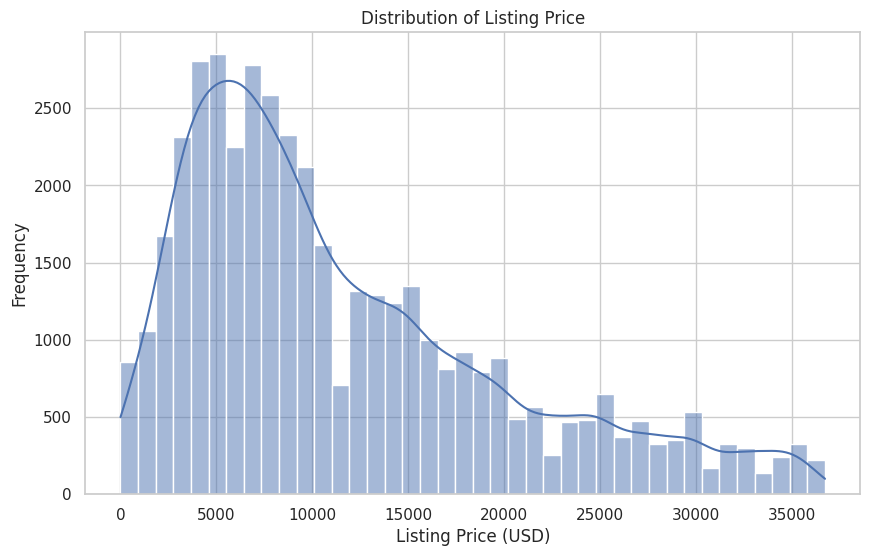

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(analysis_df["listing_price"], bins=40, kde=True)
plt.title("Distribution of Listing Price")
plt.xlabel("Listing Price (USD)")
plt.ylabel("Frequency")
plt.show()

The distribution of listing prices is positively skewed, with most vehicles concentrated in the lower-to-mid price range and a smaller number of higher-priced vehicles extending the right tail. This suggests that the median price is more representative of a typical listing than the mean.

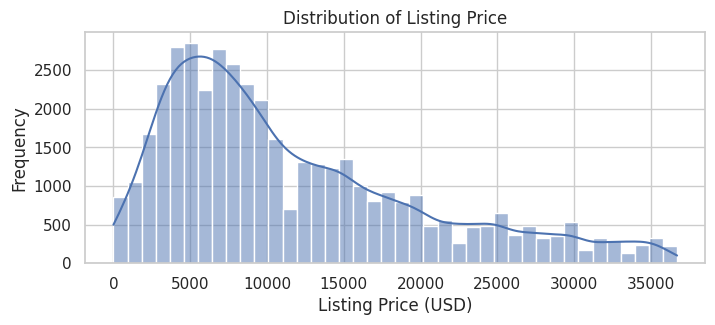

In [ ]:
plt.figure(figsize=(8,3))
sns.histplot(analysis_df["listing_price"], bins=40, kde=True)
plt.title("Distribution of Listing Price")
plt.xlabel("Listing Price (USD)")
plt.ylabel("Frequency")
plt.show()

# 7. Vehicle attributes and pricing
## 7.1 Vehicle age and price

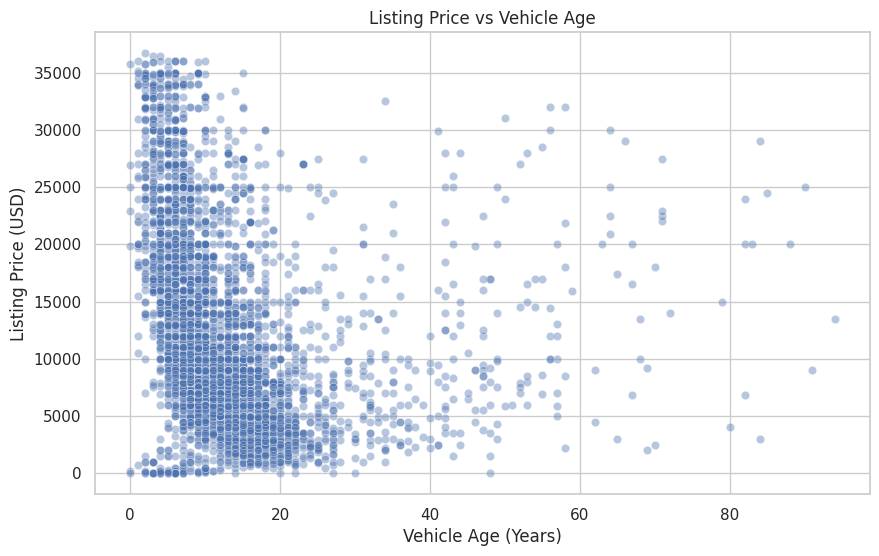

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=analysis_df.sample(min(5000, len(analysis_df)), random_state=42),
                x="vehicle_age", y="listing_price", alpha=0.4)
plt.title("Listing Price vs Vehicle Age")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Listing Price (USD)")
plt.show()

The scatter plot suggests a negative relationship between vehicle age and listing price, with newer vehicles generally listed at higher prices. However, the pattern is not strictly linear, and substantial variation remains within each age group, indicating that other factors such as maker, mileage, and condition also influence price.

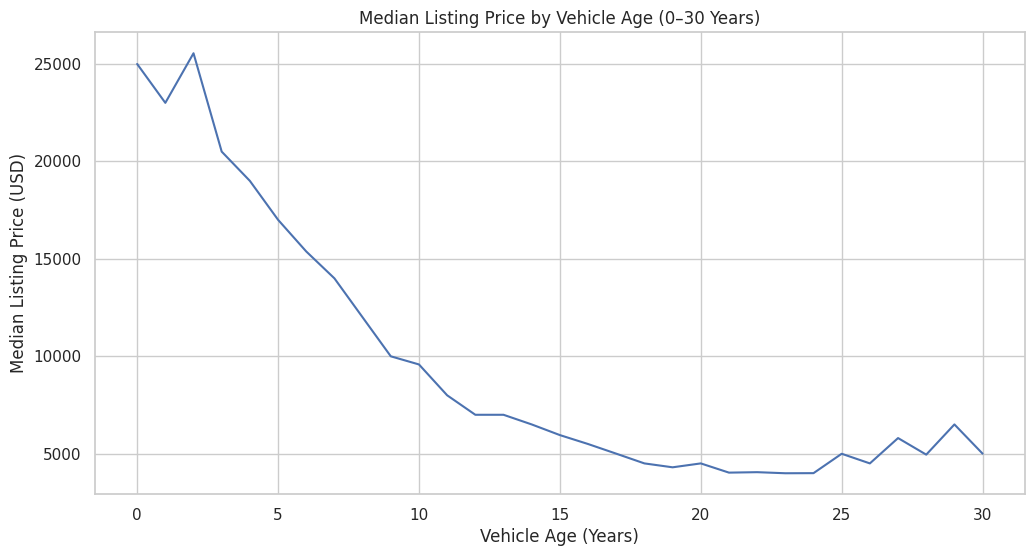

In [ ]:
age_price_filtered = analysis_df[analysis_df["vehicle_age"] <= 30] \
    .groupby("vehicle_age", as_index=False)["listing_price"].median()

plt.figure(figsize=(12,6))
sns.lineplot(data=age_price_filtered, x="vehicle_age", y="listing_price")
plt.title("Median Listing Price by Vehicle Age (0–30 Years)")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Median Listing Price (USD)")
plt.show()

Median listing prices decline as vehicle age increases, especially within the first 10 years. This suggests that vehicle depreciation is steep in the early years and becomes more gradual for older vehicles. Although some fluctuation remains among older vehicles, the overall relationship between age and price is clearly negative.

## 7.2 Mileage and price

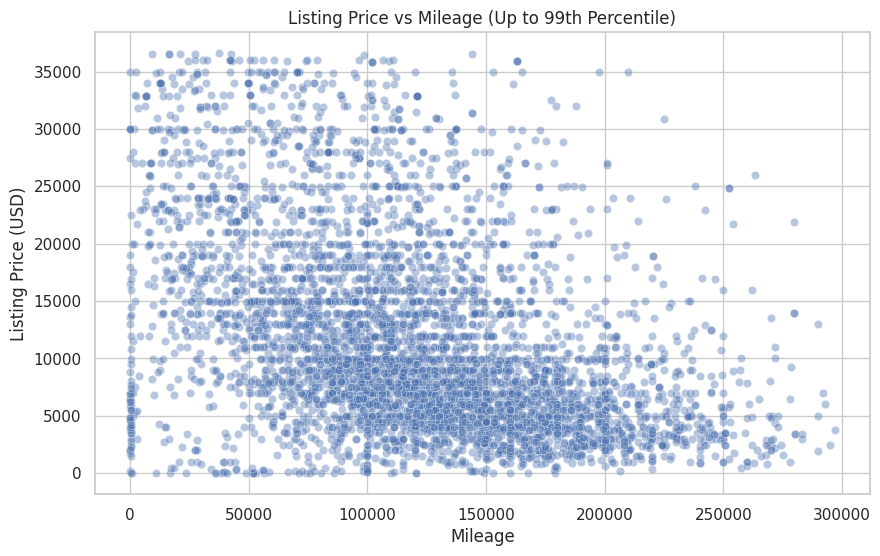

In [ ]:
mileage_upper = analysis_df["mileage"].quantile(0.99)

mileage_df = analysis_df[analysis_df["mileage"] <= mileage_upper]

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=mileage_df.sample(min(5000, len(mileage_df)), random_state=42),
    x="mileage",
    y="listing_price",
    alpha=0.4
)
plt.title("Listing Price vs Mileage (Up to 99th Percentile)")
plt.xlabel("Mileage")
plt.ylabel("Listing Price (USD)")
plt.show()

The scatter plot indicates a generally negative relationship between mileage and listing price. Vehicles with lower mileage tend to have higher prices, while higher-mileage vehicles are more concentrated in lower price ranges. However, the wide spread of prices at similar mileage levels suggests that mileage is an important, but not the only, determinant of used car prices.

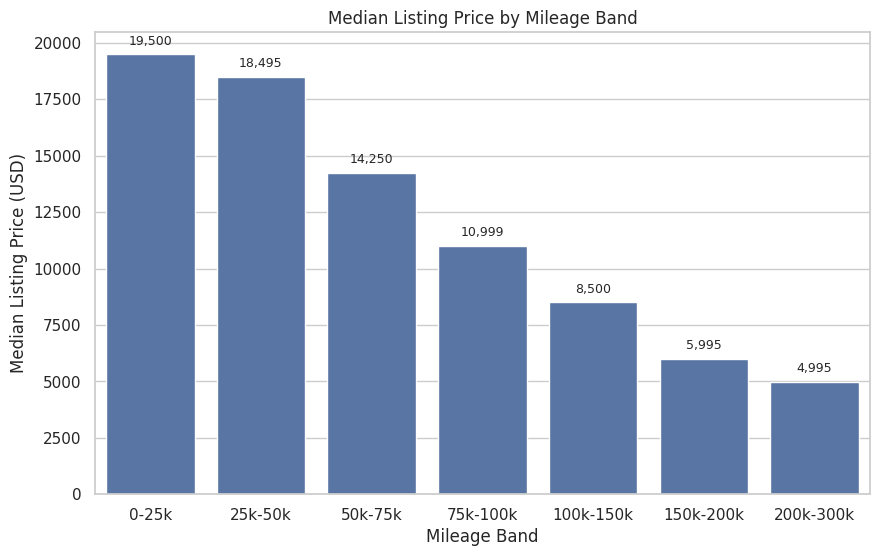

In [ ]:
# Median price by mileage band
mileage_upper = analysis_df["mileage"].quantile(0.99)
mileage_df = analysis_df[analysis_df["mileage"] <= mileage_upper].copy()

mileage_df["mileage_band"] = pd.cut(
    mileage_df["mileage"],
    bins=[0, 25000, 50000, 75000, 100000, 150000, 200000, 300000],
    labels=["0-25k", "25k-50k", "50k-75k", "75k-100k", "100k-150k", "150k-200k", "200k-300k"],
    include_lowest=True
)

mileage_band_price = (
    mileage_df.groupby("mileage_band", observed=False)["listing_price"]
    .median()
    .reset_index()
)

plt.figure(figsize=(10,6))
ax = sns.barplot(data=mileage_band_price, x="mileage_band", y="listing_price")
plt.title("Median Listing Price by Mileage Band")
plt.xlabel("Mileage Band")
plt.ylabel("Median Listing Price (USD)")

for i, value in enumerate(mileage_band_price["listing_price"]):
    ax.text(i, value + 300, f"{value:,.0f}", ha="center", va="bottom", fontsize=9)
plt.show()

## 7.3 Condition and price

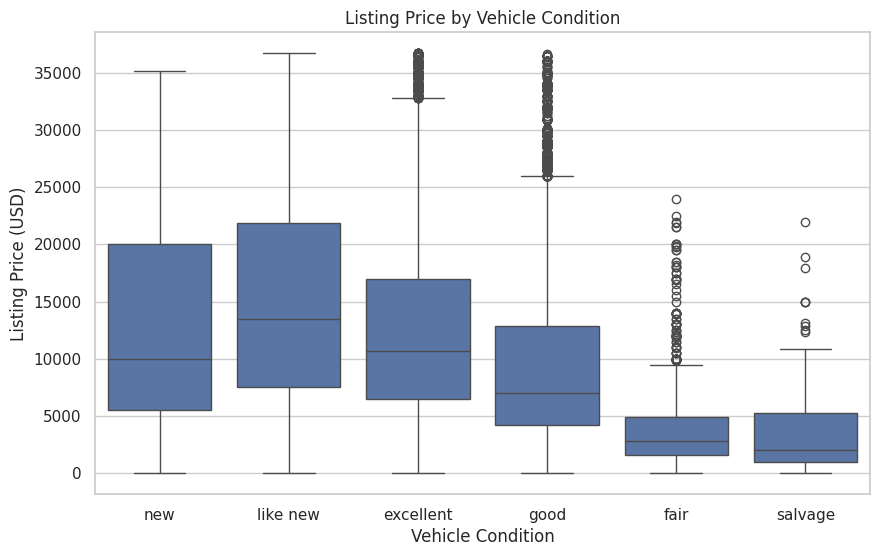

In [ ]:
condition_order = ["new", "like new", "excellent", "good", "fair", "salvage"]

condition_df = analysis_df[analysis_df["vehicle_condition"].isin(condition_order)].copy()

plt.figure(figsize=(10,6))
sns.boxplot(data=condition_df, x="vehicle_condition", y="listing_price", order=condition_order)
plt.title("Listing Price by Vehicle Condition")
plt.xlabel("Vehicle Condition")
plt.ylabel("Listing Price (USD)")
plt.show()

The relationship between vehicle condition and listing price is broadly consistent with expectations, with lower-condition vehicles generally priced lower. However, some category ordering is not perfectly monotonic, and several high-priced listings appear within the “excellent” and “good” groups. This may reflect self-reported condition labels, as well as the influence of other factors such as maker, age, and mileage.

## 7.6 Vehicle type distribution


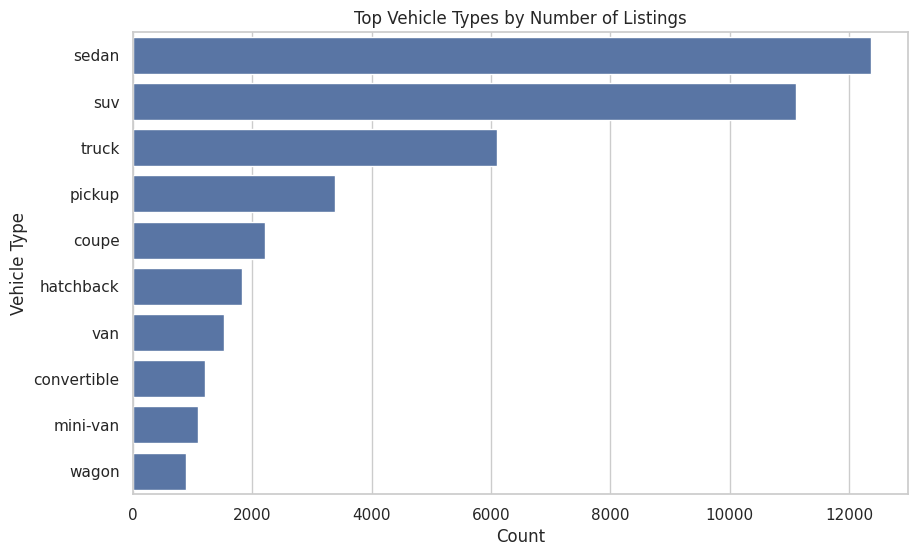

In [ ]:
top_types = analysis_df["vehicle_type"].value_counts().head(10).index
type_df = analysis_df[analysis_df["vehicle_type"].isin(top_types)]

plt.figure(figsize=(10,6))
sns.countplot(data=type_df, y="vehicle_type", order=type_df["vehicle_type"].value_counts().index)
plt.title("Top Vehicle Types by Number of Listings")
plt.xlabel("Count")
plt.ylabel("Vehicle Type")
plt.show()


Sedan and SUV listings dominate the dataset, followed by trucks, indicating that the used vehicle market is concentrated in a few major vehicle categories. This suggests that Apex Autos should pay particular attention to these segments when evaluating sourcing opportunities and inventory strategy in the U.S. market.

## 7.7 Price by vehicle type

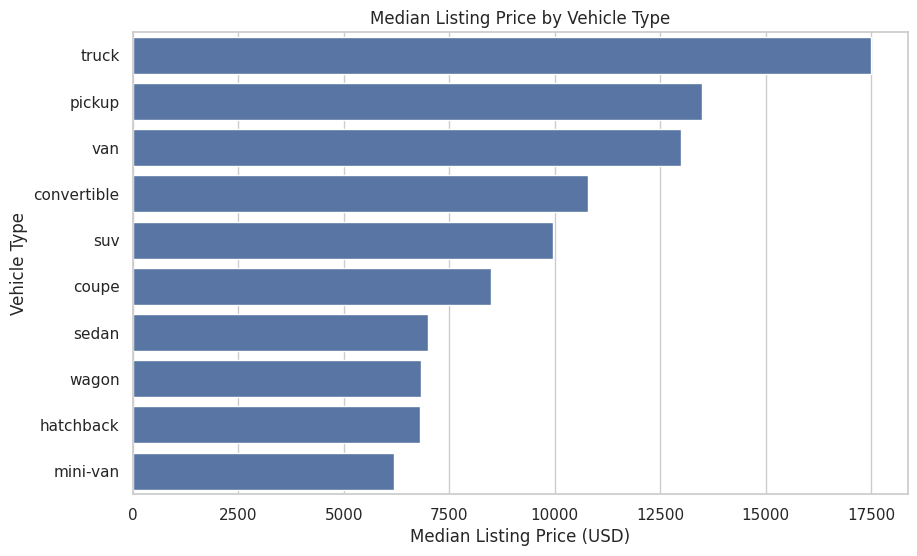

In [ ]:
type_price = (
   analysis_df[analysis_df["vehicle_type"].isin(top_types)]
   .groupby("vehicle_type")["listing_price"]
   .median()
   .sort_values(ascending=False)
   .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=type_price, x="listing_price", y="vehicle_type")
plt.title("Median Listing Price by Vehicle Type")
plt.xlabel("Median Listing Price (USD)")
plt.ylabel("Vehicle Type")
plt.show()


Vehicle type appears to be strongly associated with listing price. Utility-oriented and larger vehicle categories, such as trucks, pickups, and vans, show higher median prices than more common passenger-oriented categories such as sedans and hatchbacks. However, these differences may also reflect variation in age, mileage, and maker composition across vehicle types.

# 8. Regional analysis
## 8.1 Listings by state


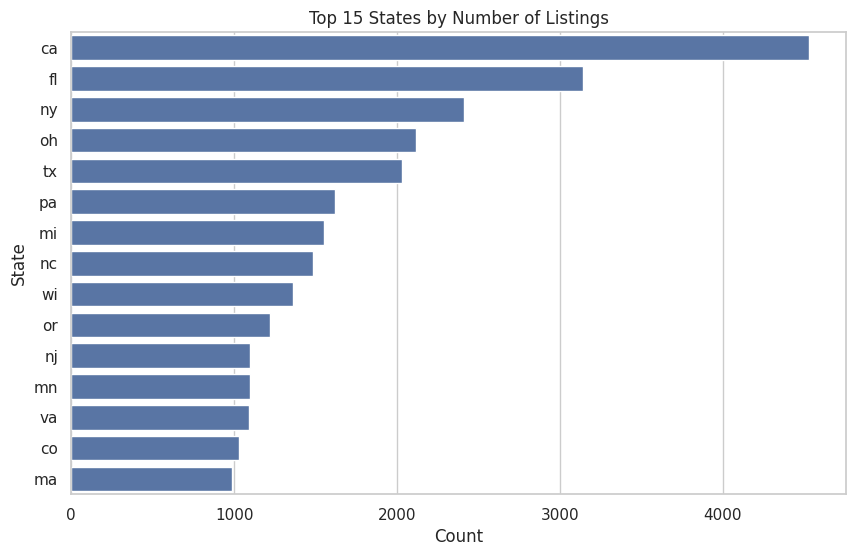

In [ ]:

top_states = analysis_df["state"].value_counts().head(15).index
state_count_df = analysis_df[analysis_df["state"].isin(top_states)]

plt.figure(figsize=(10,6))
sns.countplot(data=state_count_df, y="state", order=state_count_df["state"].value_counts().index)
plt.title("Top 15 States by Number of Listings")
plt.xlabel("Count")
plt.ylabel("State")
plt.show()


## 8.2 Median price by state

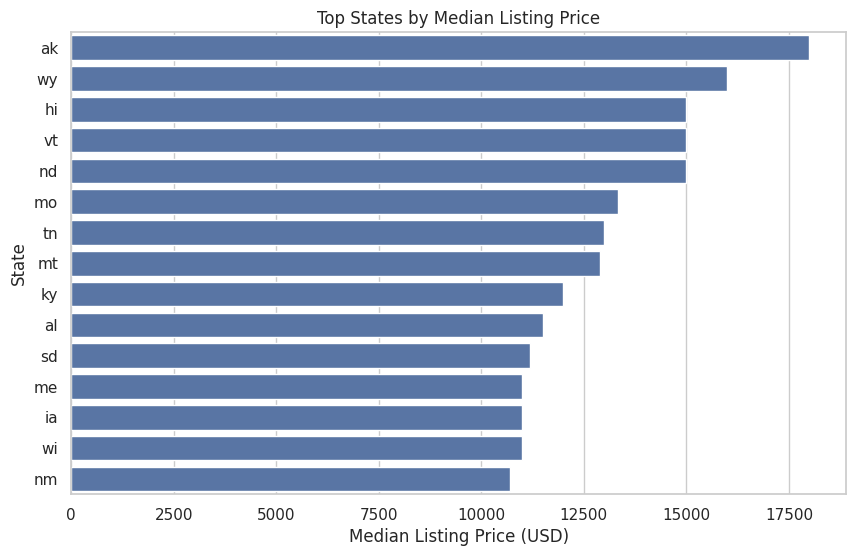

In [ ]:
state_price = (
   analysis_df.groupby("state")["listing_price"]
   .agg(["count", "median"])
   .reset_index()
)
# keep states with sufficient observations
state_price = state_price[state_price["count"] >= 30].sort_values("median", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=state_price, x="median", y="state")
plt.title("Top States by Median Listing Price")
plt.xlabel("Median Listing Price (USD)")
plt.ylabel("State")
plt.show()


California, Florida, and New York account for the largest number of listings in the dataset, indicating strong listing presence in several large and economically significant states. However, listing volume should be interpreted as an indicator of observed supply in this dataset rather than a direct measure of market attractiveness or consumer demand.

## 8.4 Vehicle type by state/region


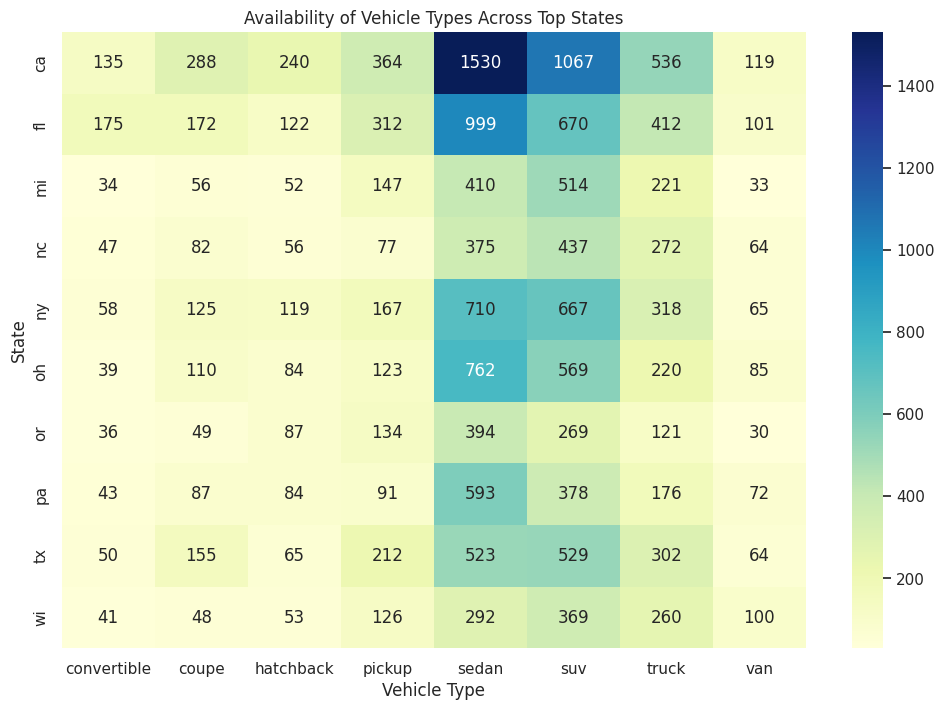

In [ ]:

# select top states and top vehicle types
top_states_heatmap = analysis_df["state"].value_counts().head(10).index
top_types_heatmap = analysis_df["vehicle_type"].value_counts().head(8).index

heatmap_df = analysis_df[
   (analysis_df["state"].isin(top_states_heatmap)) &
   (analysis_df["vehicle_type"].isin(top_types_heatmap))
]
cross_tab = pd.crosstab(heatmap_df["state"], heatmap_df["vehicle_type"])
plt.figure(figsize=(12,8))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Availability of Vehicle Types Across Top States")
plt.xlabel("Vehicle Type")
plt.ylabel("State")
plt.show()


The heatmap shows that vehicle availability differs substantially across states. Sedans and SUVs dominate listings in most states, while trucks and pickups are more prominent in some markets. This suggests that the composition of used car supply is region-specific, which has important implications for inventory sourcing and segment focus.

## 8.5 Proportional distribution by state


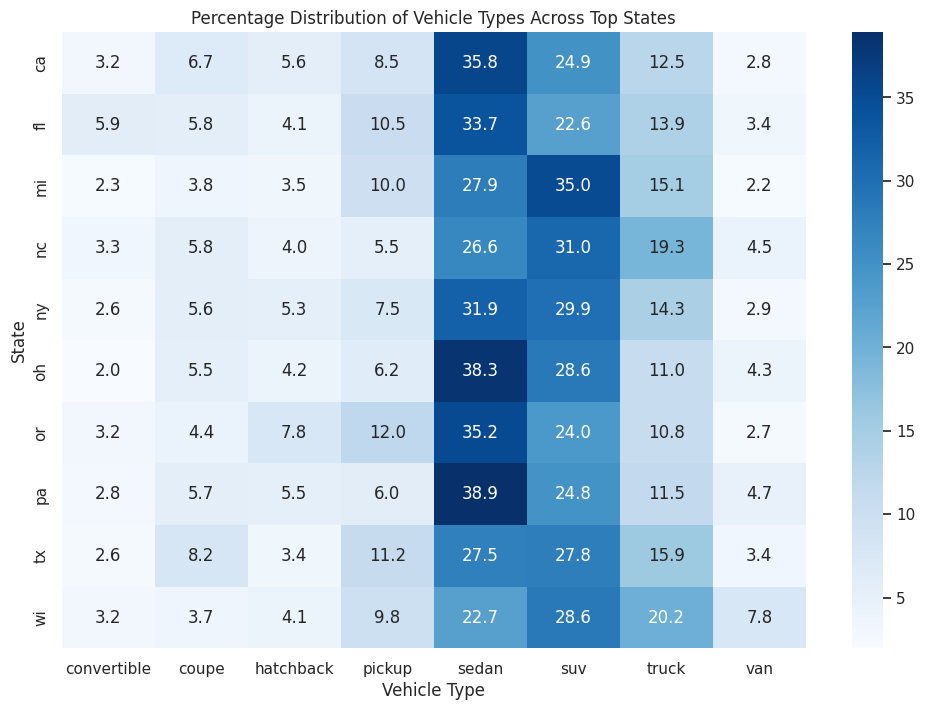

In [ ]:
prop_tab = pd.crosstab(
    heatmap_df["state"],
    heatmap_df["vehicle_type"],
    normalize="index"
) * 100

plt.figure(figsize=(12,8))
sns.heatmap(prop_tab, annot=True, fmt=".1f", cmap="Blues")
plt.title("Percentage Distribution of Vehicle Types Across Top States")
plt.xlabel("Vehicle Type")
plt.ylabel("State")
plt.show()

The proportional heatmap shows that vehicle type composition differs across states, even after controlling for differences in listing volume. While sedans and SUVs remain prominent across most states, some states show relatively stronger concentrations of trucks or pickups, suggesting that local supply structure varies by market.

## 9. Key Findings and Business Implications

### Key Findings

1. **Listing prices are positively skewed.**  
Most vehicles are concentrated in the lower-to-mid price range, while a smaller number of high-priced listings extend the upper tail. This means the median listing price is more representative than the mean for describing a typical used car listing.

2. **Vehicle age and mileage are important pricing factors.**  
Median prices decline as vehicle age increases, especially within the first 10 years, suggesting a clear depreciation pattern. Prices also decrease consistently across higher mileage bands, indicating that mileage is a major factor in vehicle valuation.

3. **Vehicle condition and vehicle type are strongly associated with price.**  
Vehicles in better reported condition tend to have higher listing prices overall, although condition labels may contain seller subjectivity. Vehicle type also matters substantially, with trucks and pickups showing higher median prices than more common passenger-oriented segments such as sedans and hatchbacks.

4. **The market is concentrated in a few major vehicle segments.**  
Sedans and SUVs account for the largest share of listings in the dataset, suggesting that these categories dominate observed used car supply. At the same time, higher-value utility-oriented segments such as trucks and pickups show stronger median prices.

5. **Regional differences are meaningful.**  
Listing activity is concentrated in a limited number of states, and vehicle-type composition differs across states. The percentage heatmap shows that some states have relatively stronger SUV or truck shares, while others are more sedan-heavy. This suggests that the U.S. used car market is not homogeneous across regions.

### Business Implications

These findings imply that Apex Autos should avoid treating the U.S. used car market as a single uniform market. Instead, expansion decisions should reflect both segment differences and regional market structure. A pricing strategy based only on average market prices would likely be inadequate, because pricing varies according to age, mileage, condition, vehicle type, and location. Similarly, an inventory strategy that ignores local vehicle mix could lead to poor product-market fit in some regions.

## 10. Recommendations for Apex Autos

1. Use a region-specific market entry strategy

2. Prioritise high-availability segments for initial market entry

3. Consider selective higher-value utility segments.

4. Build pricing benchmarks using multiple variables
5. Start with a pilot-market approach before wider rollout

## 12. Conclusion

This notebook shows that the U.S. used car market in the provided dataset is shaped by both vehicle characteristics and regional differences. Listing prices are influenced by age, mileage, condition, and vehicle type, while listing availability and segment composition vary across states. These findings suggest that Apex Autos should adopt a region-sensitive and segment-focused expansion strategy rather than relying on uniform pricing and inventory assumptions across the U.S. market.